In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys 
import os
sys.path.insert(0, os.path.join(os.path.dirname("spectra.py"), '..', 'rv-pipeline'))
from spectra import Gaussian_line

[[1.92874985e-022 1.14687658e-024 1.38389653e-087 7.95674389e-106]
 [2.35577991e-022 1.41489036e-024 2.06494396e-087 1.23574596e-105]
 [2.87620249e-022 1.74483684e-024 3.07991589e-087 1.91844324e-105]
 ...
 [2.87620249e-022 3.69241471e-020 9.99198719e-001 1.24820112e-001]
 [2.35577991e-022 3.05473135e-020 9.99799619e-001 1.29997450e-001]
 [1.92874985e-022 2.52616378e-020 1.00000000e+000 1.35335283e-001]]


SO THE *sys.path.insert(0, r"C:\Users\chand\OneDrive\Desktop\RV\rv-pipeline")*
is the code for telling python to search for Gaussian_lines a function created in another file 


In [23]:

wav = np.linspace(4990,5010,1000)
wav0 = np.array([5000.0,5002.0,5004.0,5006.0,5008.0])
sigma = 0.8
amp = 1.0

profiles = Gaussian_line(wav,wav0,sigma,amp)

assert profiles.shape == (1000,5),f"shape wrong: {profiles.shape}"
assert np.allclose(profiles[:,0],(Gaussian_line(wav,5000.0,sigma,amp))),"column 0 doesn't match"
assert np.all(profiles>=0),"negative values in profiles"
assert np.all(profiles<= amp+1e-10),"value above amplitude"

peak = Gaussian_line(np.array([5000]),5000,sigma,amp)
assert np.isclose(peak[0],1.0),'f"peak wrong = {peak wrong}"'

fwhm = 0.8*np.sqrt(2*np.log(2))
val = Gaussian_line(np.array([5000.0]+fwhm),5000.0,sigma,amp)
assert np.isclose(val[0],0.5,atol=1e-6),'f"FWHM wrong = {FWHM wrong}"'

print("all assertions passed")


all assertions passed


assert is function in which only one option is true and other is an error 

In [4]:
profiles = Gaussian_line(wav,wav0,sigma,amp)
print(profiles[0],profiles[1],profiles[2],profiles[3],profiles[4])

[2.90630936e-044 2.26143774e-063 5.90298361e-086 5.16895395e-112
 1.51837098e-141] [4.33570234e-044 3.65494286e-063 1.03358422e-085 9.80517372e-112
 3.12038987e-141] [6.46292247e-044 5.90239698e-063 1.80830645e-085 1.85848812e-111
 6.40754544e-141] [9.62609851e-044 9.52419127e-063 3.16118608e-085 3.51978517e-111
 1.31469920e-140] [1.43259531e-043 1.53560554e-062 5.52179092e-085 6.66076930e-111
 2.69533636e-140]


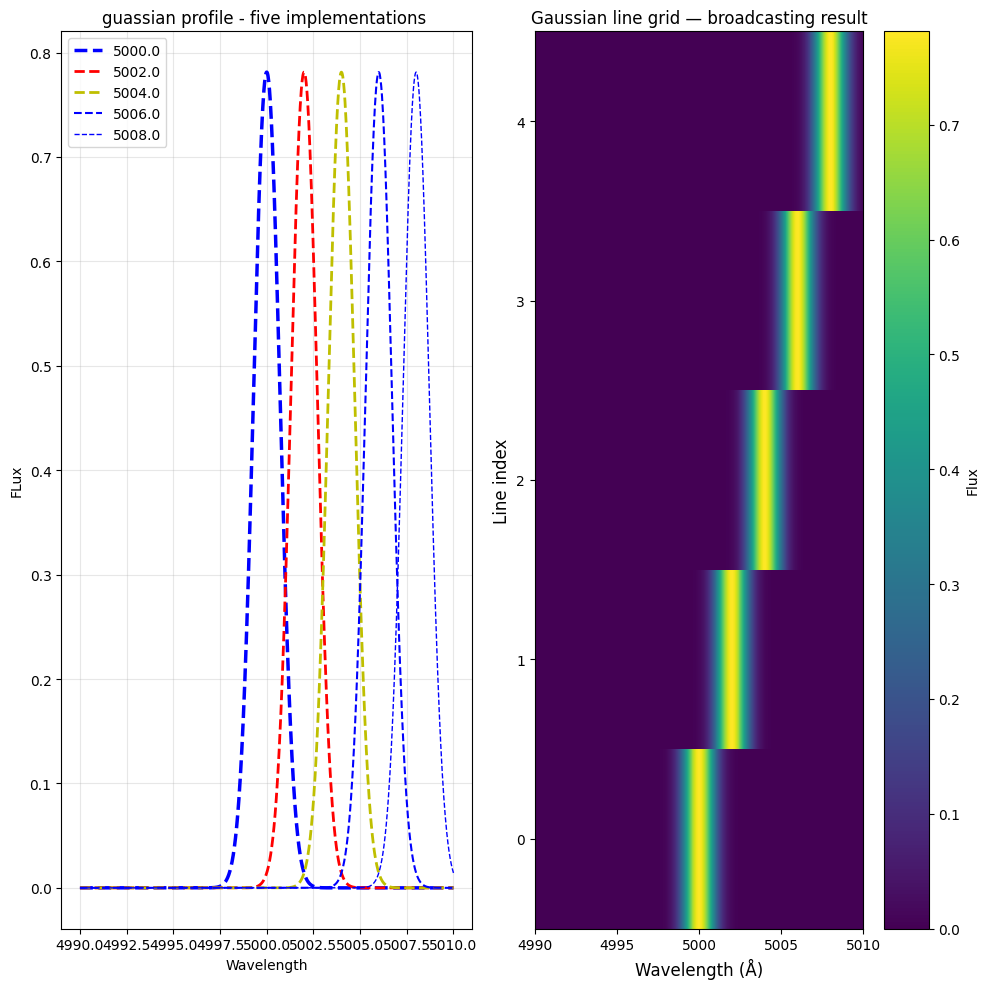

In [5]:
fig,axes = plt.subplots(1,2,figsize=(10,10))

ax = axes[0]
ax.plot(wav,profiles[:,0],'b--',linewidth = 2.5,label = '5000.0')
ax.plot(wav,profiles[:,1],'r--',linewidth = 2.,label = '5002.0')
ax.plot(wav,profiles[:,2],'y--',linewidth = 2,label = '5004.0')
ax.plot(wav,profiles[:,3],'b--',linewidth = 1.5,label = '5006.0')
ax.plot(wav,profiles[:,4],'b--',linewidth = 1,label = '5008.0')
ax.set_xlabel('Wavelength')
ax.set_ylabel('FLux')
ax.set_title('guassian profile - five implementations ')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax2 = axes[1]
c = ax2.pcolormesh(wav, np.arange(5), profiles.T,cmap='viridis', shading='auto')
plt.colorbar(c, ax=ax2, label='Flux')
ax2.set_xlabel('Wavelength (Å)', fontsize=12)
ax2.set_ylabel('Line index', fontsize=12)
ax2.set_title('Gaussian line grid — broadcasting result', fontsize=12)
plt.tight_layout()
plt.savefig('../rv-pipeline/results/day02_broadcasting_grid.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

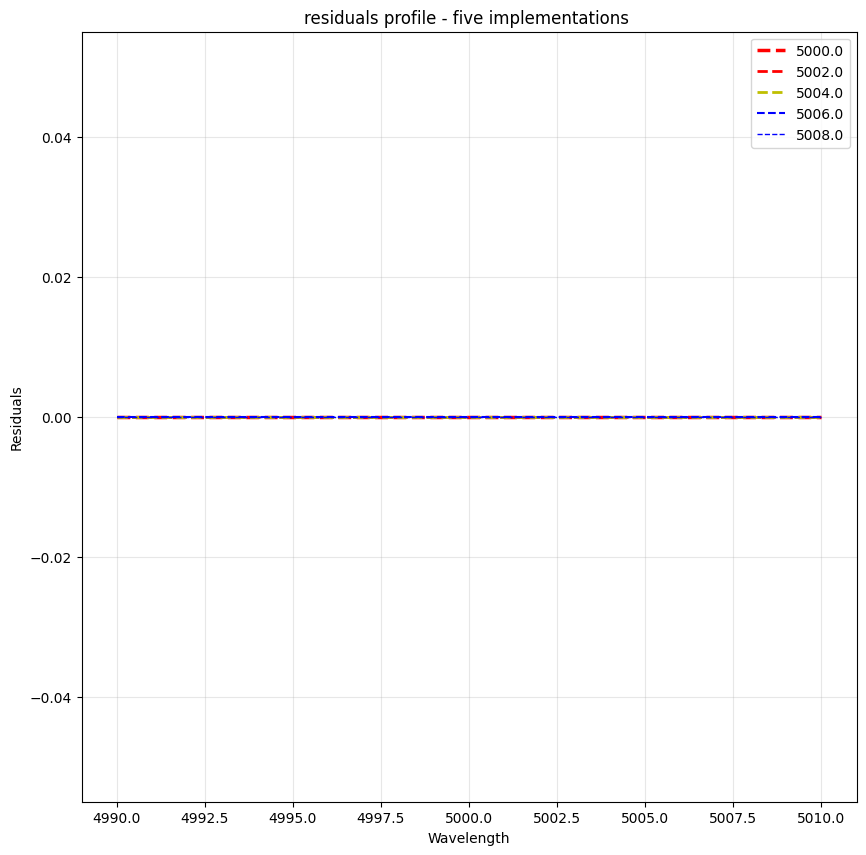

In [23]:
fig, ax3 = plt.subplots(figsize=(10, 10))

ax3.plot(wav,(profiles[:,0])-((Gaussian_line(wav,5000.0,sigma,amp))),'r--',linewidth = 2.5,label = '5000.0')
ax3.plot(wav,(profiles[:,1])-((Gaussian_line(wav,5002.0,sigma,amp))),'r--',linewidth = 2.0,label = '5002.0')
ax3.plot(wav,(profiles[:,2])-((Gaussian_line(wav,5004.0,sigma,amp))),'y--',linewidth = 2,label = '5004.0')
ax3.plot(wav,(profiles[:,3])-((Gaussian_line(wav,5006.0,sigma,amp))),'b--',linewidth = 1.5,label = '5006.0')
ax3.plot(wav,(profiles[:,4])-((Gaussian_line(wav,5008.0,sigma,amp))),'b--',linewidth = 1,label = '5008.0')
ax3.set_xlabel('Wavelength')
ax3.set_ylabel('Residuals')
ax3.set_title('residuals profile - five implementations ')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)
plt.show()

In [75]:
import timeit
for i in [5,50]:
    wav0 = np.linspace(5000,5010,i)


    N = 10000

    # 5 separate calls 
    t_scalar = timeit.timeit(lambda:[Gaussian_line(wav,i,sigma,amp)for i in wav0],number=N)/N

    t_broadcast = timeit.timeit(lambda:[Gaussian_line(wav,wav0,sigma,amp)],number=N)/N

    print(f"i={i:5d}: scalar={t_scalar*1000:.3f}ms  broadcast={t_broadcast*1000:.3f}ms  speedup={t_scalar/t_broadcast:.1f}x")





i=    5: scalar=0.259ms  broadcast=0.202ms  speedup=1.3x
i=   50: scalar=2.942ms  broadcast=2.094ms  speedup=1.4x
